## ======================================================================
## 💵 Hopify NRR & GRR Grid Plots
## ======================================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

## ================================
## 📁 Set Base Path to Project Root
## ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📥 Load Data
## ==================================================

In [2]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "02_project_revenue_profit_analysis",
    "09_hopify_nrr_grr_seg_over_time.csv"
)

df = pd.read_csv(file_path)

# ================================
# 🧼 Clean & Format Data
# ================================

In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("%", "percent")
    .str.lower()
)

df['month'] = pd.to_datetime(df['month'])
df['quarter'] = df['month'].dt.to_period('Q').astype(str)
df = df.sort_values(['customer_segment', 'quarter'])

# Aggregate to one row per Quarter per Segment
df = df.groupby(['customer_segment', 'quarter'], as_index=False).agg({
    'nrr_percent': 'mean',
    'grr_percent': 'mean'
})

# Load benchmark values
bench_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "01_benchmarks",
    "hopify_benchmarks_seg_table.csv"
)
bench_df = pd.read_csv(bench_path)
nrr_bench = bench_df[bench_df["metric_name"] == "NRR Target (%)"].set_index("segment")["target_value"].to_dict()
grr_bench = bench_df[bench_df["metric_name"] == "GRR Target (%)"].set_index("segment")["target_value"].to_dict()


## ==================================================
## 🎨 Plot Setup
## ==================================================

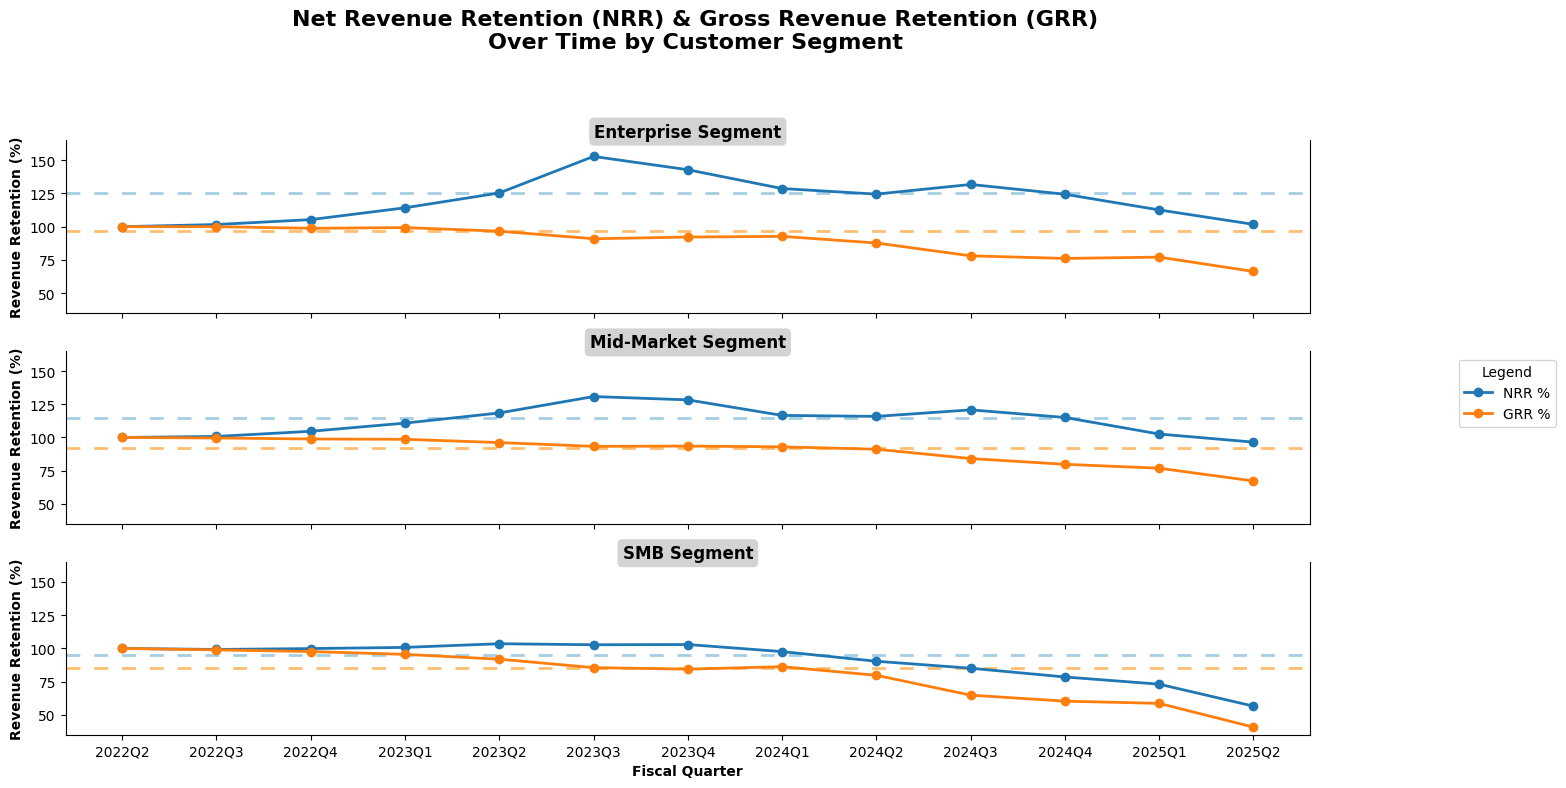

In [4]:
segments = ["Enterprise", "Mid-Market", "SMB"]
colors = {
    "NRR": "#1f77b4",
    "GRR": "#ff7f0e",
    "NRR Target": "#a6cee3",
    "GRR Target": "#fdbf6f"
}

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(14, 8), sharex=True, sharey=True)

for ax, segment in zip(axs, segments):
    seg_df = df[df["customer_segment"] == segment]

    # Plot NRR & GRR
    ax.plot(seg_df["quarter"], seg_df["nrr_percent"], marker='o', color=colors["NRR"], label="NRR %", linewidth=2, zorder=2)
    ax.plot(seg_df["quarter"], seg_df["grr_percent"], marker='o', color=colors["GRR"], label="GRR %", linewidth=2, zorder=2)

    # Add benchmarks
    if segment in nrr_bench:
        ax.axhline(y=nrr_bench[segment], linestyle=(0, (5, 5)), color=colors["NRR Target"], linewidth=2, zorder=1)
    if segment in grr_bench:
        ax.axhline(y=grr_bench[segment], linestyle=(0, (5, 5)), color=colors["GRR Target"], linewidth=2, zorder=1)

    # Axis styling
    ax.spines['top'].set_visible(False)
    ax.set_ylim(35, 165)
    ax.set_ylabel("Revenue Retention (%)", fontweight='bold')
    ax.set_title("")

    # Segment box title
    ax.text(
        0.5, 1.05, f"{segment} Segment",
        transform=ax.transAxes,
        ha='center', va='center',
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgrey', edgecolor='none')
    )

# Only label x-axis once
axs[-1].set_xlabel("Fiscal Quarter", fontweight='bold')

# Shared Legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5), title="Legend")

# Title & Save
fig.suptitle("Net Revenue Retention (NRR) & Gross Revenue Retention (GRR)\nOver Time by Customer Segment", fontsize=16, fontweight='bold')
fig.tight_layout(rect=[0, 0, 0.95, 0.93])

# ================================
# 💾 Save & Show
# ================================


In [5]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "02_project_revenue_profit_analysis",
    "hopify_nrr_grr_over_time_seg_grid.png"
)
plt.savefig(output_path, dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>